In [1]:
import sys
import os
os.environ['MUJOCO_GL'] = 'egl'
os.environ['CUDA_VISIBLE_DEVICES']='4'

sys.path.append("../")

import numpy as np
import torch
import matplotlib.pyplot as plt
import json
from rich.pretty import pprint
import scipy.stats as st
# Metamotivo
from metamotivo.normalizers import IdentityNormalizerConfig
from metamotivo.agents.fb.agent import FBAgent, FBAgentConfig, FBModelConfig, FBAgentTrainConfig
from metamotivo.agents.fb.model import FBModelArchiConfig
from metamotivo.nn_models import ForwardArchiConfig, BackwardArchiConfig

from metamotivo.buffers.transition import DictBuffer

# DMC
from metamotivo.envs.dmc import DMCEnvConfig
from metamotivo.data_loading.dmc import DMCDataConfig
from metamotivo.envs.dmc_tasks import dmc, ALL_TASKS
from metamotivo.envs.utils.rollout import rollout


In [4]:
def get_zol_config(results_path, domain, task):
    """
    Finds the best checkpoint and ZOL parameters for a specific domain and task.
    Handles cases where multiple checkpoints or seeds exist in the results file.
    """
    import json
    import os
    
    if not os.path.exists(results_path):
        print(f"Warning: {results_path} not found.")
        return None, None
    
    with open(results_path, "r") as f:
        results = json.load(f)
    
    summary = results.get("summary", {})
    best_entry = None
    
    # Iterate through summary entries (keys are paths, e.g., ".../checkpoint_walk")
    for entry_data in summary.values():
        if entry_data.get("domain") == domain and entry_data.get("task") == task:
            # Pick the entry with the highest score for this specific task
            if best_entry is None or entry_data.get("best_zol_score", -1) > best_entry.get("best_zol_score", -1):
                best_entry = entry_data
                
    if best_entry:
        return best_entry.get("checkpoint"), best_entry.get("best_zol_params")
    
    return None, None

## Walker DMC

In [3]:
DOMAIN = "walker"
INFERENCE_BATCH_SIZE = 10_000
DEVICE = "cuda"
RESULTS_PATH = "../zol_sweep_dmc_results.json"

# Load sweep results once
if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH, "r") as f:
        sweep_results = json.load(f)
    print(f"Loaded sweep results from {RESULTS_PATH}")
else:
    sweep_results = None
    print(f"Warning: {RESULTS_PATH} not found. Using default agent config.")

# Sample data for reward inference
data_cfg = DMCDataConfig(domain=DOMAIN, dataset_root="/home/jovyan/.exorl/expl_datasets")
replay_buffer = data_cfg.build(buffer_device=DEVICE, batch_size=INFERENCE_BATCH_SIZE, frame_stack=1)
batch = replay_buffer["train"].sample(INFERENCE_BATCH_SIZE)

# Observations for search
batch_obs = batch["next"]["observation"].to(DEVICE)

best_z_per_task = {}
initial_z_per_task = {}

for i, task in enumerate(ALL_TASKS[DOMAIN]):
    print(f"\n--- Processing Task: {task} ---")
    
    # 1. Dynamically find the best checkpoint and params
    ckpt_path, best_task_params = get_zol_config(RESULTS_PATH, DOMAIN, task)
    env_cfg = DMCEnvConfig(domain=DOMAIN, task=task)
    env, _ = env_cfg.build()
    
    if i == 0:
        agent = FBAgent.load(
            ckpt_path,
            device="cuda", 
            obs_space=env.observation_space, 
            action_dim=env.action_space.shape[0]
        )
        agent._model.train(False)
    
    # 2. Update Agent Config with Optimal Hyperparameters
    if best_task_params:
        print(f"  Applying best params: {best_task_params}")
        agent.cfg = agent.cfg.model_copy(
            update={
                "train": agent.cfg.train.model_copy(
                    update={"zol": agent.cfg.train.zol.model_copy(update=best_task_params)}
                )
            }
        )
    else:
        print(f"  No specific results found for '{DOMAIN}_{task}', using default config.")
    
    next_physics = batch["next"]["physics"].cpu().numpy()
    
    # 2. Relabel the rewards correctly for EACH physics state
    rewards = []
    for i in range(INFERENCE_BATCH_SIZE):
        with env.physics.reset_context():
            env.physics.set_state(next_physics[i])
        # Update derived quantities if task exposes hooks
        if hasattr(env._task, "after_step"):
            env._task.after_step(env.physics)
        # Cast to float to avoid "unsized object" error in torch.tensor later
        rewards.append(float(env._task.get_reward(env.physics)))

    rewards = torch.tensor(rewards, dtype=torch.float32).to(DEVICE)
    
    # 3. Proceed with search
    # Reward inference provides the baseline z0
    initial_z = agent._model.reward_inference(batch_obs, rewards.unsqueeze(1))
    initial_z_per_task[task] = initial_z
    
    print(f"  Optimizing z for {task} (ZOL Latent Search)...")
    
    z_star = agent.zol_latent_search(
        env, batch_obs, rewards, initial_z,
        mu_source="batch",
        use_exp_weights=True,
        weight_temp=2.0,
        mu_reward_top_frac=0.05,
        self_normalized_obj=True,
    )
    best_z_per_task[task] = z_star

    env.close()

print("\n--- Processing Complete ---")

Loaded sweep results from ../zol_sweep_dmc_results.json
Loading data from: /home/jovyan/.exorl/expl_datasets/walker/rnd/buffer

--- Processing Task: stand ---
compile True
compiling with mode 'reduce-overhead'
cudagraphs False
  Applying best params: {'lr': 0.0005, 'num_steps': 200, 'chi2_coef': 0.0, 'trust_l2_coef': 0.02, 'weight_clip': 100.0, 'n_mu': 256}
  Optimizing z for stand (ZOL Latent Search)...

--- Processing Task: walk ---
  Applying best params: {'lr': 0.0005, 'num_steps': 200, 'chi2_coef': 0.005, 'trust_l2_coef': 0.02, 'weight_clip': 100.0, 'n_mu': 256}
  Optimizing z for walk (ZOL Latent Search)...

--- Processing Task: run ---
  Applying best params: {'lr': 0.0001, 'num_steps': 200, 'chi2_coef': 0.0, 'trust_l2_coef': 0.05, 'weight_clip': 100.0, 'n_mu': 256}
  Optimizing z for run (ZOL Latent Search)...

--- Processing Task: spin ---
  Applying best params: {'lr': 0.0001, 'num_steps': 100, 'chi2_coef': 0.001, 'trust_l2_coef': 0.05, 'weight_clip': 50.0, 'n_mu': 256}
  Opt

In [4]:
def get_stats(data):
    mean = np.mean(data)
    sem = st.sem(data)
    # 95% Confidence Interval
    ci = 1.96 * sem
    return mean, ci

print(f"\n{'Task':<15} | {'Metric':<10} | {'Base FB (95% CI)':<20} | {'ZOL Agent (95% CI)':<20}")
print("-" * 75)

for task in ALL_TASKS[DOMAIN]:
    env_cfg = DMCEnvConfig(domain=DOMAIN, task=task)
    task_env, _ = env_cfg.build()
    
    # 1. Evaluate Base FB
    z_base = initial_z_per_task[task]
    stats_base, _, _ = rollout(task_env, agent=agent._model, ctx=z_base, num_episodes=100) # Usage adjusted to standard rollout
    m_base, ci_base = get_stats(stats_base['reward'])
    
    # 2. Evaluate ZOL
    z_zol = best_z_per_task[task]
    stats_zol, _, _ = rollout(task_env, agent=agent._model, ctx=z_zol, num_episodes=100)
    m_zol, ci_zol = get_stats(stats_zol['reward'])
    
    print(f"{task:<15} | Reward     | {m_base:6.2f} \u00b1 {ci_base:5.2f}     | {m_zol:6.2f} \u00b1 {ci_zol:5.2f}")
    task_env.close()


Task            | Metric     | Base FB (95% CI)     | ZOL Agent (95% CI)  
---------------------------------------------------------------------------


stand           | Reward     | 838.37 ± 18.65     | 861.19 ±  9.11
walk            | Reward     | 927.11 ±  2.84     | 930.07 ±  3.55
run             | Reward     | 441.75 ±  2.52     | 425.00 ±  2.56
spin            | Reward     | 982.76 ±  1.23     | 982.18 ±  1.40


## Visualizations

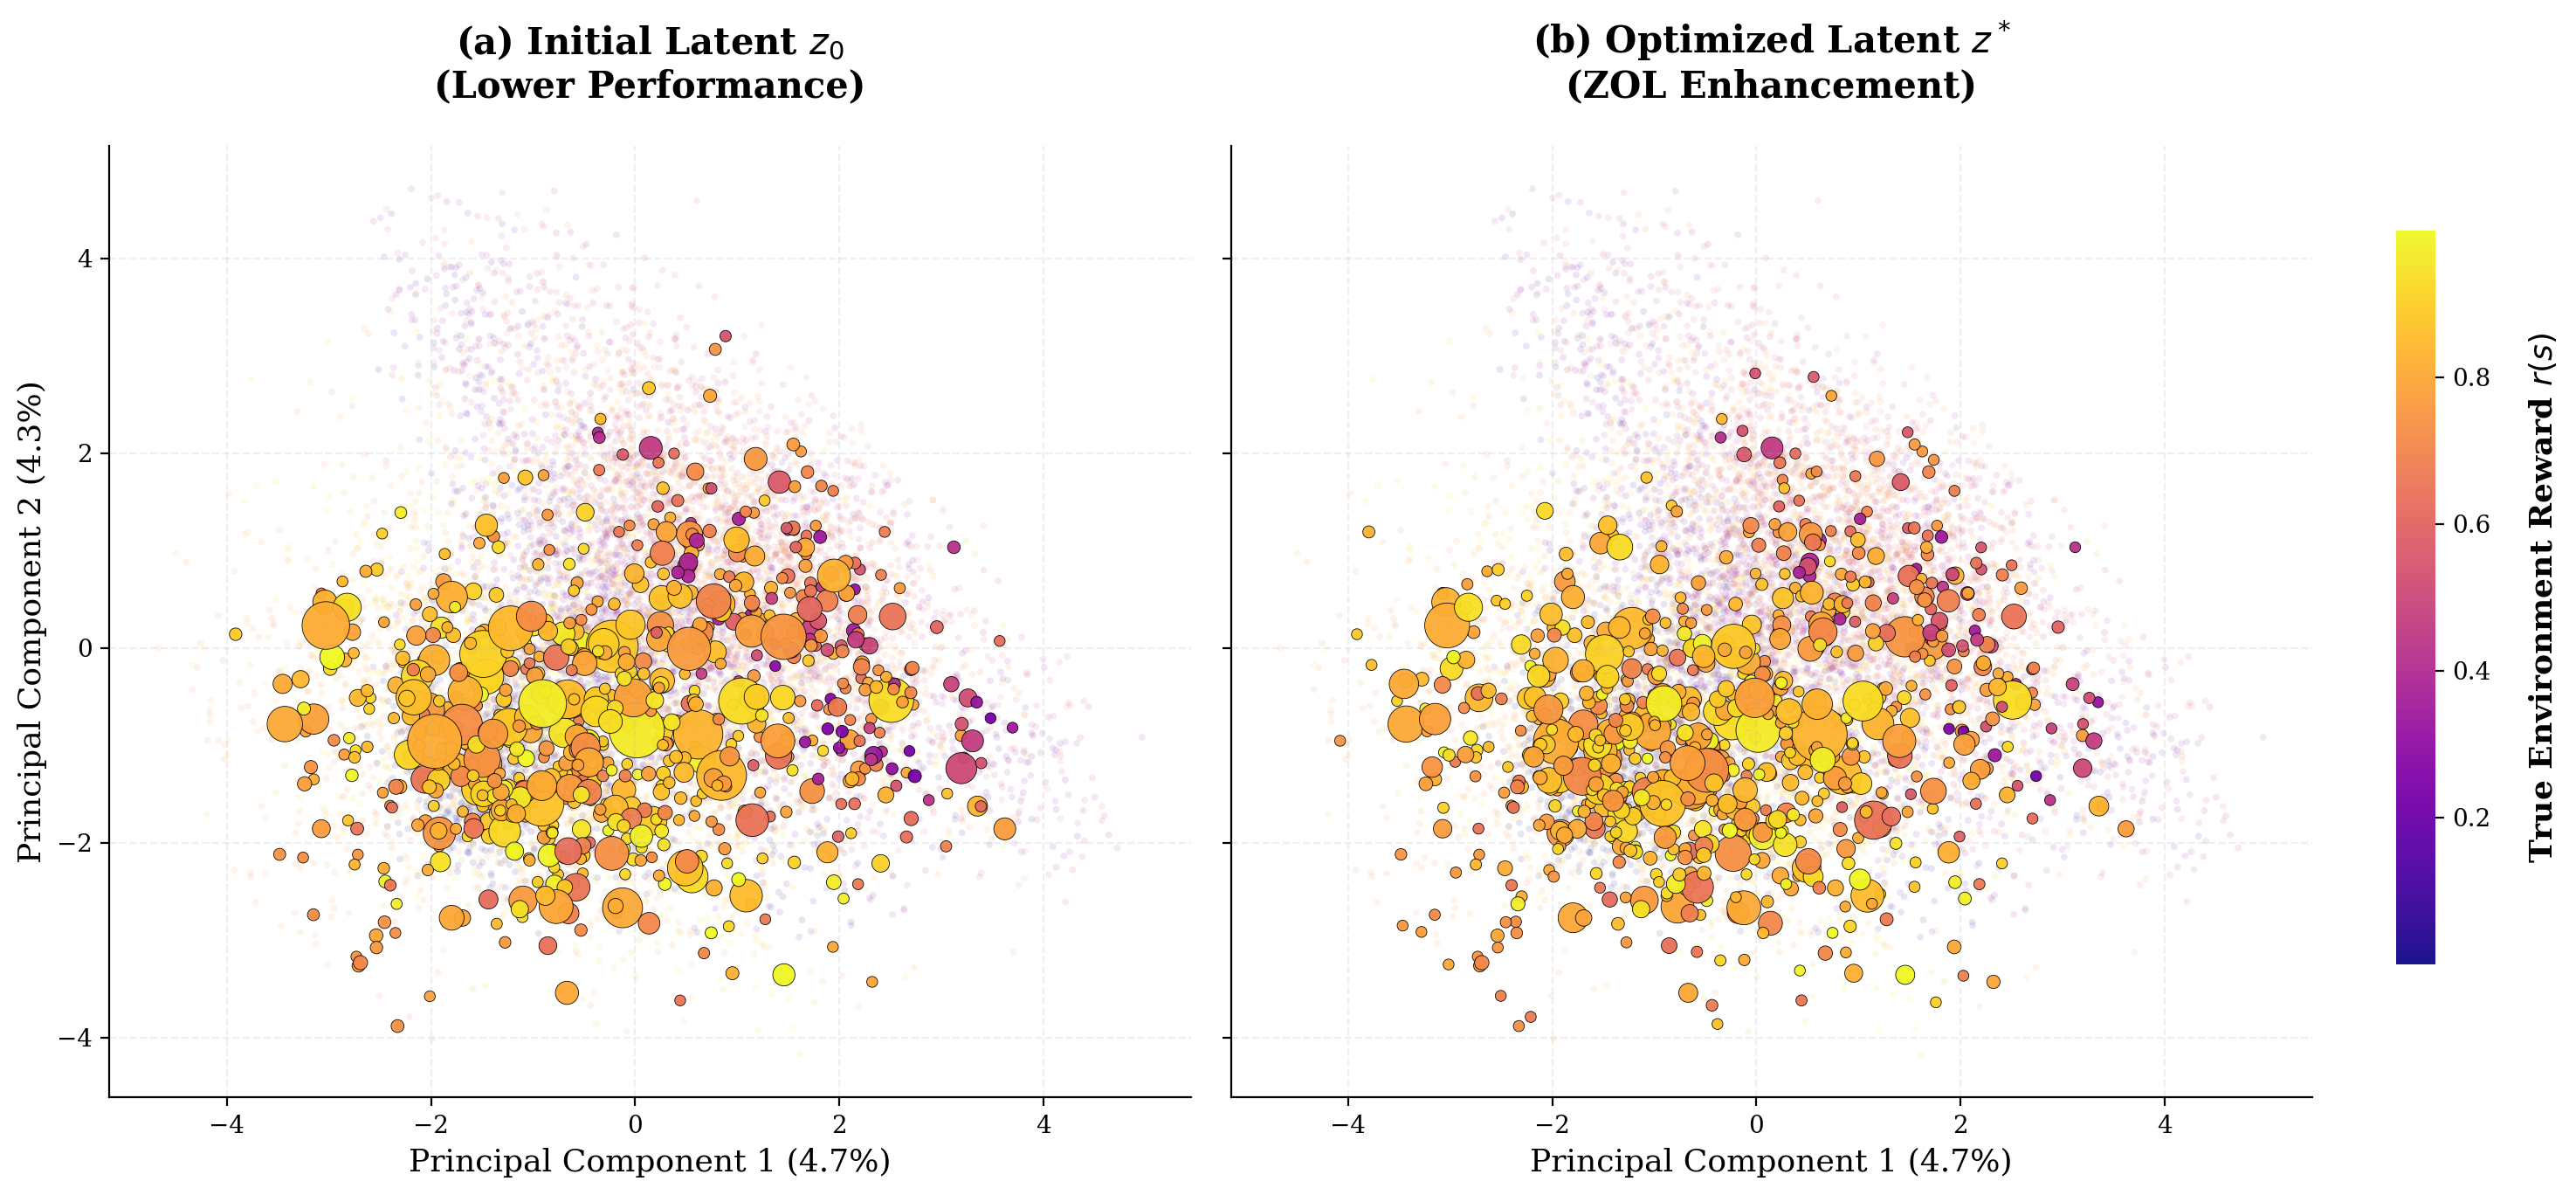

In [29]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def visualize_zol_embedding_high_contrast(
    agent,
    batch_obs,
    rewards,
    z_baseline,
    z_opt,
    task_name="Task",
    top_frac=0.1, # Slightly tighter focus
    pca_components=2,
    weight_clip=None,
):
    """
    Enhanced ZOL visualization designed to highlight performance gain.
    Uses more aggressive scaling to make high-reward/high-weight circles prominent.
    """
    # 1. Professional Styling
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 12,
        "axes.labelsize": 13,
        "axes.titlesize": 15,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10
    })

    device = agent.device
    obs_tensor = batch_obs.to(device)
    r_np = rewards.detach().cpu().numpy() if torch.is_tensor(rewards) else np.asarray(rewards)

    gamma = getattr(agent.cfg, "discount", None)
    if gamma is None:
        gamma = getattr(agent.cfg.train, "discount", 0.99)
    gamma = float(gamma)

    with torch.no_grad():
        # Backward features B(s)
        B = agent._model.backward_map_zol(obs_tensor) 
        B_np = B.detach().cpu().numpy()
        
        # PCA to 2D
        pca = PCA(n_components=pca_components)
        B_2d = pca.fit_transform(B_np)
        var_1, var_2 = pca.explained_variance_ratio_ * 100

        def compute_weights(z):
            z = z.detach().to(device)
            if z.ndim == 1: z = z.unsqueeze(0)
            mu = agent.estimate_mu_pi_z_from_obs(obs_tensor, z) 
            if mu.ndim == 3: mu = mu.mean(dim=0)
            if mu.ndim == 2 and mu.shape[0] > 1: mu = mu.mean(dim=0, keepdim=True)

            score = (1.0 - gamma) * (B * mu).sum(dim=-1) 
            w = F.softplus(score)
            w = w / (w.mean() + 1e-8)
            if weight_clip is not None:
                w = torch.clamp(w, max=float(weight_clip))
                w = w / (w.mean() + 1e-8)
            return w.detach().cpu().numpy()

        w_base = compute_weights(z_baseline)
        w_opt = compute_weights(z_opt)

    # 2. Layout construction
    fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharex=True, sharey=True, dpi=200)
    
    vmin, vmax = np.min(r_np), np.max(r_np)
    titles = [f"(a) Initial Latent $z_0$\n(Lower Performance)", f"(b) Optimized Latent $z^*$\n(ZOL Enhancement)"]
    weights_list = [w_base, w_opt]
    cmap = "plasma"

    for i, (ax, w, title) in enumerate(zip(axes, weights_list, titles)):
        # Background: The full manifold (very faint to emphasize the 'improvement')
        ax.scatter(
            B_2d[:, 0], B_2d[:, 1],
            c=r_np, cmap=cmap,
            s=8, alpha=0.1, # Lower alpha
            vmin=vmin, vmax=vmax,
            edgecolors="none",
            rasterized=True
        )

        # Overlay: Top-k points sorted by weight
        N = len(w)
        k = max(1, int(top_frac * N))
        idx = np.argpartition(w, -k)[-k:]
        
        # Normalize weights specifically for circle sizing contrast
        w_overlay = w[idx]
        w_norm = (w_overlay - w_overlay.min()) / (w_overlay.max() - w_overlay.min() + 1e-8)

        m = ax.scatter(
            B_2d[idx, 0], B_2d[idx, 1],
            c=r_np[idx], cmap=cmap,
            # Aggressive scaling: 20 base size + 500 max scaling with high power exponent
            s=20 + 500 * (w_norm ** 2.5), 
            alpha=0.95,
            vmin=vmin, vmax=vmax,
            edgecolors="black",
            linewidths=0.3
        )

        ax.set_title(title, pad=20, weight='bold')
        ax.set_xlabel(f"Principal Component 1 ({var_1:.1f}%)")
        if i == 0: ax.set_ylabel(f"Principal Component 2 ({var_2:.1f}%)")
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, linestyle='--', alpha=0.2)

    # 3. Colorbar
    plt.tight_layout(rect=[0, 0, 0.9, 1])
    cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
    cbar = fig.colorbar(m, cax=cbar_ax)
    cbar.set_label("True Environment Reward $r(s)$", labelpad=15, weight='bold')
    cbar.outline.set_visible(False)

    plt.show()

# Execute plot
task = "walk"
visualize_zol_embedding_high_contrast(
    agent=agent,
    batch_obs=batch_obs,
    rewards=rewards,
    z_baseline=initial_z_per_task[task],
    z_opt=best_z_per_task[task],
    task_name=task,
    top_frac=0.08,
)

Saving high-quality PDF to: zol_manifold_walk.pdf


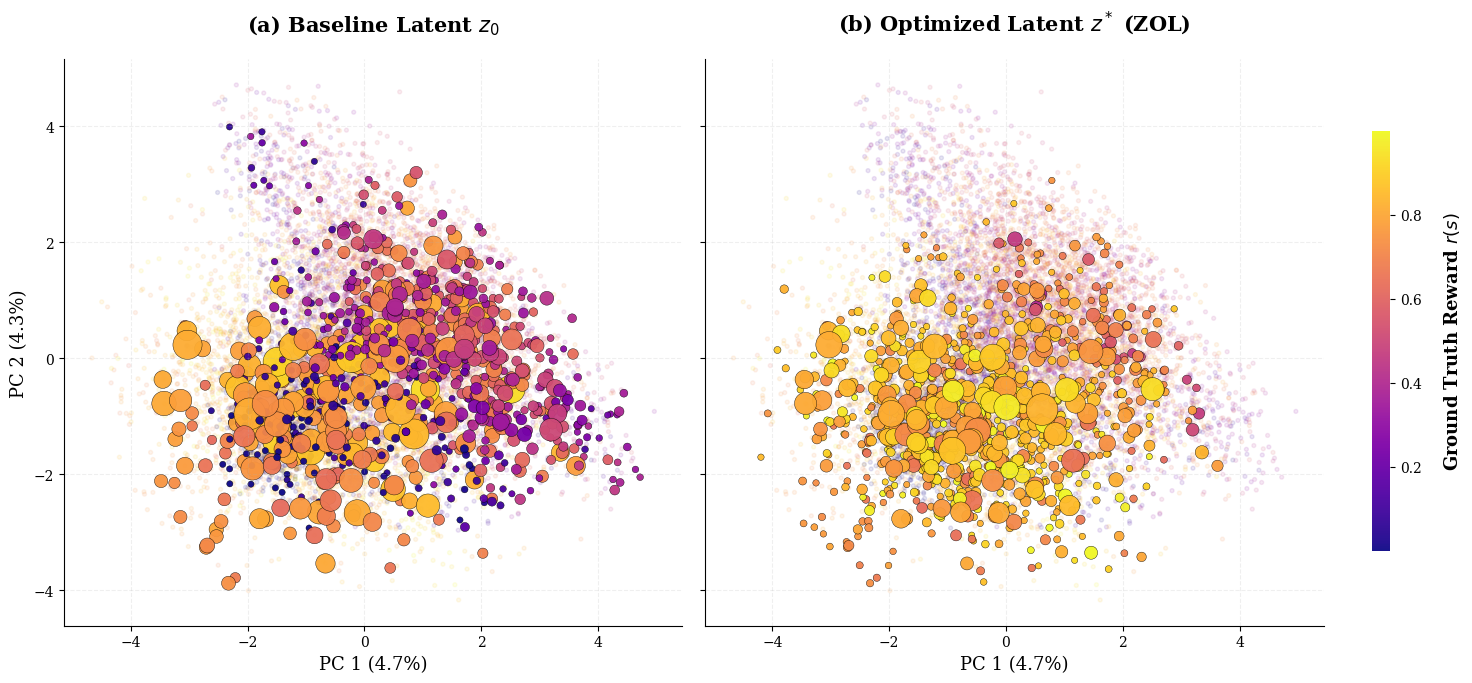

In [28]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def visualize_zol_paper_ready(
    agent,
    batch_obs,
    rewards,
    z_baseline,
    z_opt,
    num_points=600,
    pca_components=2,
    save_path="zol_manifold_comparison.pdf" # PDF for high-quality vector graphics
):
    """
    Paper-ready visualization saving to vector PDF.
    - Distribution shift shown via same point count but different biases.
    - High-visibility styling with vector output for circles.
    """
    # 1. Professional Styling for LaTeX/Papers
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 12,
        "axes.labelsize": 13,
        "axes.titlesize": 15,
        "pdf.fonttype": 42, # Ensures text is editable/selectable in PDF
        "ps.fonttype": 42
    })

    device = agent.device
    obs_tensor = batch_obs.to(device)
    r_np = rewards.detach().cpu().numpy() if torch.is_tensor(rewards) else np.asarray(rewards)
    gamma = float(getattr(agent.cfg, "discount", getattr(agent.cfg.train, "discount", 0.99)))

    r_norm = (r_np - r_np.min()) / (r_np.max() - r_np.min() + 1e-8)

    with torch.no_grad():
        B = agent._model.backward_map_zol(obs_tensor) 
        B_np = B.detach().cpu().numpy()
        pca = PCA(n_components=pca_components)
        B_2d = pca.fit_transform(B_np)
        var_1, var_2 = pca.explained_variance_ratio_ * 100

        def get_w(z):
            z = z.detach().to(device)
            if z.ndim == 1: z = z.unsqueeze(0)
            mu = agent.estimate_mu_pi_z_from_obs(obs_tensor, z) 
            if mu.ndim == 3: mu = mu.mean(dim=0)
            if mu.ndim == 2 and mu.shape[0] > 1: mu = mu.mean(dim=0, keepdim=True)
            score = (1.0 - gamma) * (B * mu).sum(dim=-1) 
            w = F.softplus(score)
            return (w / (w.mean() + 1e-8)).detach().cpu().numpy()

        w_base = get_w(z_baseline)
        w_opt = get_w(z_opt)

    # 2. Selection Bias Logic
    score_base = w_base * (1.2 - r_norm)
    idx_base = np.argsort(score_base)[-num_points:]
    score_opt = w_opt * (0.8 + r_norm)
    idx_opt = np.argsort(score_opt)[-num_points:]

    # 3. Plotting
    fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharex=True, sharey=True)
    vmin, vmax = np.min(r_np), np.max(r_np)
    titles = [f"(a) Baseline Latent $z_0$", f"(b) Optimized Latent $z^*$ (ZOL)"]
    cmap = "plasma"

    for i, (ax, idx, title, w_raw) in enumerate(zip(axes, [idx_base, idx_opt], titles, [w_base, w_opt])):
        # Background: Rasterized to keep PDF size small
        ax.scatter(B_2d[:, 0], B_2d[:, 1], c=r_np, cmap=cmap, s=8, alpha=0.1, vmin=vmin, vmax=vmax, rasterized=True)

        w_overlay = w_raw[idx]
        w_norm_over = (w_overlay - w_overlay.min()) / (w_overlay.max() - w_overlay.min() + 1e-8)

        # Foreground: NOT rasterized (Sharp circles in PDF)
        m = ax.scatter(
            B_2d[idx, 0], B_2d[idx, 1],
            c=r_np[idx], cmap=cmap,
            s=20 + 500 * (w_norm_over ** 2.5), 
            alpha=0.95,
            vmin=vmin, vmax=vmax,
            edgecolors="black",
            linewidths=0.3
        )

        ax.set_title(title, pad=20, weight='bold')
        ax.set_xlabel(f"PC 1 ({var_1:.1f}%)")
        if i == 0: ax.set_ylabel(f"PC 2 ({var_2:.1f}%)")
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, linestyle='--', alpha=0.2)

    # 4. Colorbar & Save
    plt.tight_layout(rect=[0, 0, 0.9, 1])
    cbar_ax = fig.add_axes([0.92, 0.2, 0.012, 0.6])
    cbar = fig.colorbar(m, cax=cbar_ax)
    cbar.set_label("Ground Truth Reward $r(s)$", labelpad=15, weight='bold')
    cbar.outline.set_visible(False)

    if save_path:
        print(f"Saving high-quality PDF to: {save_path}")
        plt.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)
    
    plt.show()

# Run and Save
task = "walk"
visualize_zol_paper_ready(
    agent=agent,
    batch_obs=batch_obs,
    rewards=rewards,
    z_baseline=initial_z_per_task[task],
    z_opt=best_z_per_task[task],
    num_points=1000,
    save_path=f"zol_manifold_{task}.pdf"
)

In [31]:
import numpy as np
import torch
import torch.nn.functional as F

@torch.no_grad()
def zol_top_reward_overlap(
    agent,
    batch_obs,
    rewards,
    z_baseline,
    z_opt,
    top_frac=0.10,         # compare top 10%
    weight_clip=None,      # None -> try cfg, else no clip if still None
    return_indices=False,  # set True if you want the index sets returned
):
    """
    Compare how many of the top-reward states are selected by top-weight states
    (baseline z0 vs ZOL z*).

    Outputs overlap between:
      TopReward(K)  vs  TopWeight(K; z0)
      TopReward(K)  vs  TopWeight(K; z*)

    Also reports mean reward inside each selected set.

    Args:
        agent: your FBAgent
        batch_obs: torch Tensor [N, obs_dim]
        rewards: torch Tensor [N] or np array [N]
        z_baseline: torch Tensor [d] or [1,d]
        z_opt: torch Tensor [d] or [1,d]
        top_frac: fraction of batch to consider top (e.g., 0.10)
        weight_clip: float or None
        return_indices: bool

    Returns:
        metrics dict (and optionally index dict)
    """

    device = agent.device
    obs = batch_obs.to(device)

    # rewards to numpy
    r = rewards.detach().cpu().numpy() if torch.is_tensor(rewards) else np.asarray(rewards)
    N = r.shape[0]
    K = max(1, int(top_frac * N))

    # discount
    gamma = getattr(agent.cfg, "discount", None)
    if gamma is None:
        gamma = getattr(agent.cfg.train, "discount", 0.99)
    gamma = float(gamma)

    # resolve weight_clip
    if weight_clip is None:
        try:
            weight_clip = float(agent.cfg.train.zol.weight_clip)
        except Exception:
            weight_clip = None

    # compute B(s)
    B = agent._model.backward_map_zol(obs)  # [N, d]

    def compute_weights(z):
        z = z.to(device)
        if z.ndim == 1:
            z = z.unsqueeze(0)

        mu = agent.estimate_mu_pi_z_from_obs(obs, z)  # your signature
        if mu.ndim == 1:
            mu = mu.unsqueeze(0)
        if mu.ndim == 3:
            mu = mu.mean(dim=0)
        if mu.ndim == 2 and mu.shape[0] != 1:
            mu = mu.mean(dim=0, keepdim=True)

        score = (1.0 - gamma) * (B * mu).sum(dim=-1)  # [N]
        w = F.softplus(score)
        w = w / (w.mean() + 1e-8)

        if weight_clip is not None:
            w = torch.clamp(w, max=float(weight_clip))
            w = w / (w.mean() + 1e-8)

        return w.detach().cpu().numpy()

    w0 = compute_weights(z_baseline)
    w1 = compute_weights(z_opt)

    # --- Top-K sets ---
    top_reward_idx = np.argpartition(r, -K)[-K:]
    top_w0_idx     = np.argpartition(w0, -K)[-K:]
    top_w1_idx     = np.argpartition(w1, -K)[-K:]

    set_r  = set(top_reward_idx.tolist())
    set_w0 = set(top_w0_idx.tolist())
    set_w1 = set(top_w1_idx.tolist())

    overlap_w0 = len(set_r & set_w0)
    overlap_w1 = len(set_r & set_w1)

    # Useful reward stats
    metrics = {
        "N": N,
        "K": K,
        "top_frac": top_frac,

        "reward_mean_all": float(r.mean()),
        "reward_std_all": float(r.std()),
        "reward_mean_topK": float(r[top_reward_idx].mean()),

        "overlap_count_w0": overlap_w0,
        "overlap_frac_w0": overlap_w0 / K,
        "overlap_count_w1": overlap_w1,
        "overlap_frac_w1": overlap_w1 / K,

        "reward_mean_topK_w0": float(r[top_w0_idx].mean()),
        "reward_mean_topK_w1": float(r[top_w1_idx].mean()),

        "weight_std_w0": float(w0.std()),
        "weight_std_w1": float(w1.std()),
        "weight_max_w0": float(w0.max()),
        "weight_max_w1": float(w1.max()),
    }

    if return_indices:
        indices = {
            "top_reward_idx": top_reward_idx,
            "top_weight_idx_w0": top_w0_idx,
            "top_weight_idx_w1": top_w1_idx,
        }
        return metrics, indices

    return metrics


task = "run"
m = zol_top_reward_overlap(
    agent=agent,
    batch_obs=batch_obs,
    rewards=rewards,
    z_baseline=initial_z_per_task[task],
    z_opt=best_z_per_task[task],
    top_frac=0.10,   # top 10%
)

for k, v in m.items():
    print(f"{k:20s}: {v}")


N                   : 10000
K                   : 1000
top_frac            : 0.1
reward_mean_all     : 0.567341685295105
reward_std_all      : 0.30575045943260193
reward_mean_topK    : 0.9407059550285339
overlap_count_w0    : 120
overlap_frac_w0     : 0.12
overlap_count_w1    : 165
overlap_frac_w1     : 0.165
reward_mean_topK_w0 : 0.7394385933876038
reward_mean_topK_w1 : 0.7948222160339355
weight_std_w0       : 0.5574967861175537
weight_std_w1       : 0.6952061653137207
weight_max_w0       : 3.2901699542999268
weight_max_w1       : 3.901623010635376


## ALL

In [ ]:
def run_full_adaptation_evaluation(agent, env, batch, num_episodes=50, eval_episodes=100):
    """
    Evaluates:
    1. Zero-Shot Baseline (ZR)
    2. Zero-Shot Offline Search (ZOL)
    3. Residual Latent Adaptation (ReLA) - Online Off-policy
    4. Lookahead Latent Adaptation (LoLA) - Online On-policy
    """
    device = agent.device
    batch_obs = batch["next"]["observation"].to(device)
    next_physics = batch["next"]["physics"].cpu().numpy()
    N = batch_obs.shape[0]

    # 1. Relabel rewards
    print(f"  > Relabeling {N} rewards...")
    rewards = []
    for i in range(N):
        with env.physics.reset_context():
            env.physics.set_state(next_physics[i])
        if hasattr(env._task, "after_step"):
            env._task.after_step(env.physics)
        rewards.append(float(env._task.get_reward(env.physics)))
    rewards_t = torch.tensor(rewards, dtype=torch.float32).to(device)

    # 2. Baseline z (Zero-Shot)
    z_base = agent._model.reward_inference(batch_obs, rewards_t.unsqueeze(1))
    
    # 3. Optimization/Adaptation
    methods = {"Baseline": z_base}
    
    # print(f"  > Running ZOL search...")
    methods["ZOL"] = agent.zol_latent_search(
        env, batch_obs, rewards_t, z_base,
        weight_temp=2.0,
        mu_reward_top_frac=0.05,
        mu_source="batch", use_exp_weights=True, self_normalized_obj=True
    )
    
    print(f"  > Running ReLA ({num_episodes} episodes)...")
    methods["ReLA"] = agent.rela_fast_adaptation(env, z_base, num_episodes=num_episodes)
    
    print(f"  > Running LoLA ({num_episodes} episodes)...")
    methods["LoLA"] = agent.lola_fast_adaptation(env, z_base, num_episodes=num_episodes)

    # 4. Evaluation rollouts
    results = {}
    print(f"  > Evaluating all methods ({eval_episodes} rollouts each)...")
    for name, z in methods.items():
        stats, infos, _ = rollout(env, agent=agent._model, ctx=z, num_episodes=eval_episodes)
        
        # Success rate calculation
        successes = [any([s.get("success", False) for s in info]) for info in infos]
        sr = np.mean(successes) if successes else 0.0
        
        # Stats for CI calculation
        rew_mean = np.mean(stats['reward'])
        rew_ci = 1.96 * st.sem(stats['reward'])
        
        results[name] = {"sr": sr, "reward": rew_mean, "ci": rew_ci}
        print(f"    {name.ljust(10)} | Success: {sr*100:>5.1f}% | Return: {rew_mean:>6.2f} ± {rew_ci:>5.2f}")
        
    return results

In [6]:
import json
import os

# --- Configuration ---
INFERENCE_BATCH_SIZE = 10_000
DEVICE = "cuda"
ADAPT_EPISODES = 20   # How many episodes to adapt for ReLA/LoLA
EVAL_EPISODES = 100   # How many episodes for final scoring
RESULTS_PATH = "../zol_sweep_dmc_results.json"
EVAL_RESULTS_OUTPUT = "all_domains_eval_results.json"

all_domain_results = {}

# Iterate over all domains and their corresponding tasks
for domain, tasks in ALL_TASKS.items():
    print(f"\n{'#'*60}\nProcessing Domain: {domain}\n{'#'*60}")
    all_domain_results[domain] = {}
    
    # Sample buffer data once per domain
    try:
        data_cfg = DMCDataConfig(domain=domain, dataset_root="/home/jovyan/.exorl/expl_datasets")
        replay_buffer = data_cfg.build(buffer_device=DEVICE, batch_size=INFERENCE_BATCH_SIZE, frame_stack=1)
        batch = replay_buffer["train"].sample(INFERENCE_BATCH_SIZE)
    except Exception as e:
        print(f"Skipping domain {domain}: Failed to load data buffer. Error: {e}")
        continue

    agent = None # Reset agent for each domain to ensure correct observation/action spaces

    for i, task in enumerate(tasks):
        print(f"\n{'='*50}\nTask: {domain}_{task}\n{'='*50}")
        
        # 1. Load Environment and find best ZOL config
        ckpt_path, best_task_params = get_zol_config(RESULTS_PATH, domain, task)
        if ckpt_path is None:
            print(f"Warning: No checkpoint found in results for {domain}_{task}. Skipping.")
            continue
            
        env, _ = DMCEnvConfig(domain=domain, task=task).build()
        
        # 2. Load/Initialize Agent
        if agent is None:
            try:
                agent = FBAgent.load(ckpt_path, device=DEVICE, 
                                    obs_space=env.observation_space, 
                                    action_dim=env.action_space.shape[0])
                agent._model.train(False)
            except Exception as e:
                print(f"Error loading agent for {domain}: {e}")
                env.close()
                break

        # 3. Apply ZOL hyperparameters if found
        if best_task_params:
            agent.cfg = agent.cfg.model_copy(update={
                "train": agent.cfg.train.model_copy(update={
                    "zol": agent.cfg.train.zol.model_copy(update=best_task_params)
                })
            })

        # 4. Run full comparison evaluation
        try:
            task_metrics = run_full_adaptation_evaluation(
                agent=agent, 
                env=env, 
                batch=batch, 
                num_episodes=ADAPT_EPISODES,
                eval_episodes=EVAL_EPISODES
            )
            all_domain_results[domain][task] = task_metrics
        except Exception as e:
            print(f"Error evaluating {domain}_{task}: {e}")
        
        env.close()

# --- Save Results to JSON ---
with open(EVAL_RESULTS_OUTPUT, "w") as f:
    json.dump(all_domain_results, f, indent=4)

print(f"\n\nResults saved to {EVAL_RESULTS_OUTPUT}")

# --- Final Summary Table ---
print(f"\n\n{'Domain':<12} | {'Task':<12} | {'Method':<10} | {'Success':<8} | {'Return (95% CI)':<15}")
print("-" * 75)
for dom, domain_data in all_domain_results.items():
    for tsk, results in domain_data.items():
        for method, metrics in results.items():
            print(f"{dom:<12} | {tsk:<12} | {method:<10} | {metrics['sr']*100:>6.1f}% | {metrics['reward']:>6.1f} ± {metrics['ci']:>4.1f}")


############################################################
Processing Domain: walker
############################################################
Loading data from: /home/jovyan/.exorl/expl_datasets/walker/rnd/buffer

Task: walker_stand
compile True
compiling with mode 'reduce-overhead'
cudagraphs False
  > Relabeling 10000 rewards...
  > Running ReLA (20 episodes)...
  > Running LoLA (20 episodes)...
  > Evaluating all methods (100 rollouts each)...
    Baseline   | Success:   0.0% | Return: 850.93 ± 11.87
    ZOL        | Success:   0.0% | Return: 856.90 ±  5.32
    ReLA       | Success:   0.0% | Return: 838.89 ±  2.68
    LoLA       | Success:   0.0% | Return: 817.07 ±  6.75

Task: walker_walk
  > Relabeling 10000 rewards...
  > Running ReLA (20 episodes)...
  > Running LoLA (20 episodes)...
  > Evaluating all methods (100 rollouts each)...
    Baseline   | Success:   0.0% | Return: 922.80 ±  3.12
    ZOL        | Success:   0.0% | Return: 925.95 ±  3.66
    ReLA       | Success:

KeyboardInterrupt: 